# Converting Energy Demand and Power Production TSF to Pandas Dataframe
Essentialy, this is just imported code from a github repository provided. It takes the TSF data file and converts it into a Pandas Dataframe for use in Python  

In [1]:
from datetime import datetime
from distutils.util import strtobool

import pandas as pd


# Converts the contents in a .tsf file into a dataframe and returns it along with other meta-data of the dataset: frequency, horizon, whether the dataset contains missing values and whether the series have equal lengths
#
# Parameters
# full_file_path_and_name - complete .tsf file path
# replace_missing_vals_with - a term to indicate the missing values in series in the returning dataframe
# value_column_name - Any name that is preferred to have as the name of the column containing series values in the returning dataframe
def convert_tsf_to_dataframe(
    full_file_path_and_name,
    replace_missing_vals_with="NaN",
    value_column_name="series_value",
):
    col_names = []
    col_types = []
    all_data = {}
    line_count = 0
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    found_data_tag = False
    found_data_section = False
    started_reading_data_section = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            # Strip white space from start/end of line
            line = line.strip()

            if line:
                if line.startswith("@"):  # Read meta-data
                    if not line.startswith("@data"):
                        line_content = line.split(" ")
                        if line.startswith("@attribute"):
                            if (
                                len(line_content) != 3
                            ):  # Attributes have both name and type
                                raise Exception("Invalid meta-data specification.")

                            col_names.append(line_content[1])
                            col_types.append(line_content[2])
                        else:
                            if (
                                len(line_content) != 2
                            ):  # Other meta-data have only values
                                raise Exception("Invalid meta-data specification.")

                            if line.startswith("@frequency"):
                                frequency = line_content[1]
                            elif line.startswith("@horizon"):
                                forecast_horizon = int(line_content[1])
                            elif line.startswith("@missing"):
                                contain_missing_values = bool(
                                    strtobool(line_content[1])
                                )
                            elif line.startswith("@equallength"):
                                contain_equal_length = bool(strtobool(line_content[1]))

                    else:
                        if len(col_names) == 0:
                            raise Exception(
                                "Missing attribute section. Attribute section must come before data."
                            )

                        found_data_tag = True
                elif not line.startswith("#"):
                    if len(col_names) == 0:
                        raise Exception(
                            "Missing attribute section. Attribute section must come before data."
                        )
                    elif not found_data_tag:
                        raise Exception("Missing @data tag.")
                    else:
                        if not started_reading_data_section:
                            started_reading_data_section = True
                            found_data_section = True
                            all_series = []

                            for col in col_names:
                                all_data[col] = []

                        full_info = line.split(":")

                        if len(full_info) != (len(col_names) + 1):
                            raise Exception("Missing attributes/values in series.")

                        series = full_info[len(full_info) - 1]
                        series = series.split(",")

                        if len(series) == 0:
                            raise Exception(
                                "A given series should contains a set of comma separated numeric values. At least one numeric value should be there in a series. Missing values should be indicated with ? symbol"
                            )

                        numeric_series = []

                        for val in series:
                            if val == "?":
                                numeric_series.append(replace_missing_vals_with)
                            else:
                                numeric_series.append(float(val))

                        if numeric_series.count(replace_missing_vals_with) == len(
                            numeric_series
                        ):
                            raise Exception(
                                "All series values are missing. A given series should contains a set of comma separated numeric values. At least one numeric value should be there in a series."
                            )

                        all_series.append(pd.Series(numeric_series).array)

                        for i in range(len(col_names)):
                            att_val = None
                            if col_types[i] == "numeric":
                                att_val = int(full_info[i])
                            elif col_types[i] == "string":
                                att_val = str(full_info[i])
                            elif col_types[i] == "date":
                                att_val = datetime.strptime(
                                    full_info[i], "%Y-%m-%d %H-%M-%S"
                                )
                            else:
                                raise Exception(
                                    "Invalid attribute type."
                                )  # Currently, the code supports only numeric, string and date types. Extend this as required.

                            if att_val is None:
                                raise Exception("Invalid attribute value.")
                            else:
                                all_data[col_names[i]].append(att_val)

                line_count = line_count + 1

        if line_count == 0:
            raise Exception("Empty file.")
        if len(col_names) == 0:
            raise Exception("Missing attribute section.")
        if not found_data_section:
            raise Exception("Missing series information under data section.")

        all_data[value_column_name] = all_series
        loaded_data = pd.DataFrame(all_data)

        return (
            loaded_data,
            frequency,
            forecast_horizon,
            contain_missing_values,
            contain_equal_length,
        )


# Example of usage
# loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe("TSForecasting/tsf_data/sample.tsf")

# print(loaded_data)
# print(frequency)
# print(forecast_horizon)
# print(contain_missing_values)
# print(contain_equal_length)

In [2]:
testing_dataset = convert_tsf_to_dataframe(r"C:\Users\alpay\Downloads\phase_1_data.tsf",replace_missing_vals_with="NaN",value_column_name="series_value")

# Converting the Solar DataFrame to a Timeseries
To actually analyse the data, the dataframe has to be converted to a timeseries dataframe. Originally, the dataset from converting the dataset only provided each Building and Respective Solar, the time which the data for each buildings data starts, and the actual values of the time series in a list.

Essentially a new dataset was made with index starting from the earliest recorded time from all the buildings and Solar, to the end of September, as according to the project. After, the Buildings and Solar from the original data set were made the columns of the new time_series data set.

To fill in the new dataset, the list of the time series for each building were set to start when the timestamp was, alllocated to the specific timeseries row in the new dataset. With this, the new dataset was now a timeseries with all values for each building and solar in each correct sport respecitvely.

In [3]:
real_set = testing_dataset[0]
real_set


,series_name,start_timestamp,series_value
0,Building0,2016-07-03 21:30:00,"[283.8, 283.8, 283.8, 606.0, 606.0, 606.0, 606..."
1,Building1,2019-01-09 23:15:00,"[8.1, 15.7, 22.8, 32.7, 8.1, 16.5, 24.7, 34.5,..."
2,Building3,2016-03-01 04:15:00,"[1321.0, 1321.0, 1321.0, 1321.0, 1293.0, 1293...."
3,Building4,2019-07-03 04:45:00,"[2.0, NaN, 1.0, 2.0, NaN, 2.0, NaN, NaN, 2.0, ..."
4,Building5,2019-07-25 23:00:00,"[30.0, 31.0, 24.0, 34.0, 30.0, 31.0, 26.0, 33...."
5,Building6,2019-07-25 01:45:00,"[36.8, 34.6, 34.6, 36.2, 36.2, 35.2, 35.2, 35...."
6,Solar0,2020-04-25 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,Solar1,2018-12-31 13:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,Solar2,2019-06-05 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,Solar3,2019-06-05 14:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [4]:
index = pd.date_range(start="2016-03-01 04:15:00", end="2020-09-30 23:59:45", freq="15min")
new_headers = real_set["series_name"].dropna().unique().tolist()

series_testing_dataset = pd.DataFrame(columns = new_headers,index = index)

for _, row in real_set.iterrows():

    column = row.series_name
    start_time = pd.to_datetime(row.start_timestamp)
    values = row.series_value

    start_time_index = series_testing_dataset.index.get_loc(start_time)

    series_testing_dataset.iloc[0:start_time_index, series_testing_dataset.columns.get_loc(column)] = 0
    series_testing_dataset.iloc[start_time_index:start_time_index + len(values),series_testing_dataset.columns.get_loc(column)] = values

series_testing_dataset = series_testing_dataset.apply(pd.to_numeric,errors='coerce')
series_testing_dataset

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 04:15:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:30:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:45:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:00:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:15:00,0.0,0.0,1293.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,96.9,14.4,389.0,NaN,NaN,35.6,29.67,6.68,6.34,5.49,4.55,25.28
2020-09-30 23:00:00,96.9,18.8,389.0,1.0,NaN,38.6,29.94,6.71,6.39,5.65,4.57,25.30
2020-09-30 23:15:00,37.4,4.5,415.0,NaN,NaN,38.6,34.02,8.13,7.71,6.83,5.32,28.62
2020-09-30 23:30:00,37.4,9.6,415.0,NaN,NaN,38.6,38.10,9.55,9.03,8.02,6.08,31.94


# Importing Weather Data & Shortening for Usage

In [5]:
Weather_dataset = pd.read_csv(r"C:\Users\alpay\Downloads\ERA5_Weather_Data_Monash.csv")

Weather_dataset.index = Weather_dataset["datetime (UTC)"]
Weather_dataset.set_index("datetime (UTC)", inplace = True)


Weather_dataset.index = pd.to_datetime(Weather_dataset.index)

Start_index = Weather_dataset.index.get_loc("2016-03-01 04:00:00")


New_Weatherset = Weather_dataset.drop(index = Weather_dataset.index[:54028], columns = ["model (name)", "coordinates (lat,lon)", "utc_offset (hrs)"])


New_Weatherset.describe()


,model elevation (surface),temperature (degC),dewpoint_temperature (degC),wind_speed (m/s),mean_sea_level_pressure (Pa),relative_humidity ((0-1)),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2),total_cloud_cover (0-1)
count,4.602900e+04,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000,46029.000000
mean,6.959000e+01,14.752891,9.384980,3.977453,101618.236471,0.725954,179.984864,324.575807,0.599573
std,2.749830e-11,5.551882,3.590544,2.067155,876.393865,0.158980,262.233411,33.044109,0.355192
min,6.959000e+01,0.880000,-2.320000,0.020000,96728.250000,0.130000,0.000000,232.150000,0.000000
25%,6.959000e+01,10.830000,6.750000,2.350000,101151.350000,0.620000,0.000000,300.470000,0.300000
50%,6.959000e+01,13.900000,9.000000,3.760000,101694.910000,0.750000,6.300000,322.910000,0.670000
75%,6.959000e+01,17.910000,11.680000,5.350000,102196.590000,0.850000,311.410000,347.260000,0.950000
max,6.959000e+01,40.360000,22.180000,12.830000,103397.530000,1.000000,1103.920000,458.760000,1.000000


# Solar Data Analysis of Shape and Outliers

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

series_testing_dataset.describe()

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
count,113379.000000,160695.000000,160222.000000,143122.000000,130791.000000,158528.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000
mean,205.808722,4.275045,517.935702,0.242115,2.183889,7.631906,0.414900,0.739693,0.541974,0.392017,0.322501,1.450757
std,144.741018,7.339685,273.806102,0.560595,7.746851,13.560105,3.011701,2.321565,1.881633,1.338929,1.136258,5.661619
min,0.000000,0.000000,85.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,157.300000,0.000000,308.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,197.400000,0.000000,392.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,271.000000,7.100000,723.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6781.500000,83.500000,8556.000000,5.000000,62.000000,102.200000,50.410000,13.040000,13.960000,11.040000,8.100000,40.430000


In [7]:
series_testing_dataset

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 04:15:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:30:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 04:45:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:00:00,0.0,0.0,1321.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
2016-03-01 05:15:00,0.0,0.0,1293.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-30 22:45:00,96.9,14.4,389.0,NaN,NaN,35.6,29.67,6.68,6.34,5.49,4.55,25.28
2020-09-30 23:00:00,96.9,18.8,389.0,1.0,NaN,38.6,29.94,6.71,6.39,5.65,4.57,25.30
2020-09-30 23:15:00,37.4,4.5,415.0,NaN,NaN,38.6,34.02,8.13,7.71,6.83,5.32,28.62
2020-09-30 23:30:00,37.4,9.6,415.0,NaN,NaN,38.6,38.10,9.55,9.03,8.02,6.08,31.94


In [8]:
series_testing_dataset.isna().sum()
for column in series_testing_dataset.columns:
    start_timestamp = real_set.loc[real_set['series_name'] == column, 'start_timestamp'].iloc[0]
    
    Ratio = (series_testing_dataset[column].isna().sum()/series_testing_dataset[column].iloc[series_testing_dataset.index.get_loc(start_timestamp):].size) *100
    print(column, Ratio)

Building0 31.8553860627646
Building1 0.14549542846750327
Building3 0.34891748505749987
Building4 40.36154215325548
Building5 72.14471278745309
Building6 5.413255875363085
Solar0 0.0
Solar1 0.0
Solar2 0.0
Solar3 0.0
Solar4 0.0
Solar5 0.0


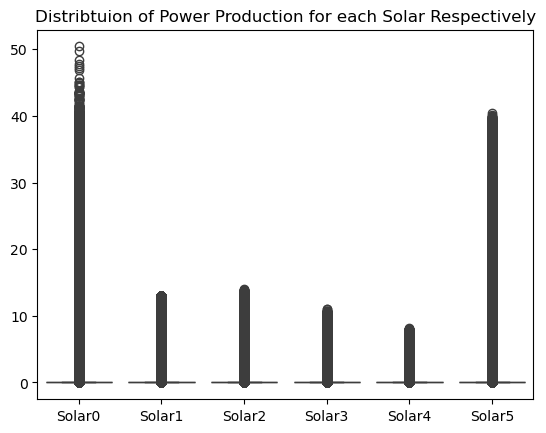

In [17]:
sns.boxplot(data = series_testing_dataset.iloc[:, 6:])
plt.title("Distribtuion of Power Production for each Solar Respectively");

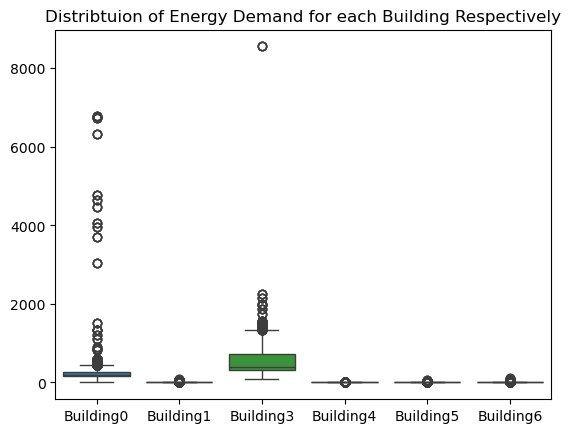

In [18]:
sns.boxplot(data = series_testing_dataset.iloc[:, :6])
plt.title("Distribtuion of Energy Demand for each Building Respectively");

Text(0.5, 1.0, 'Correlation of Buildings')

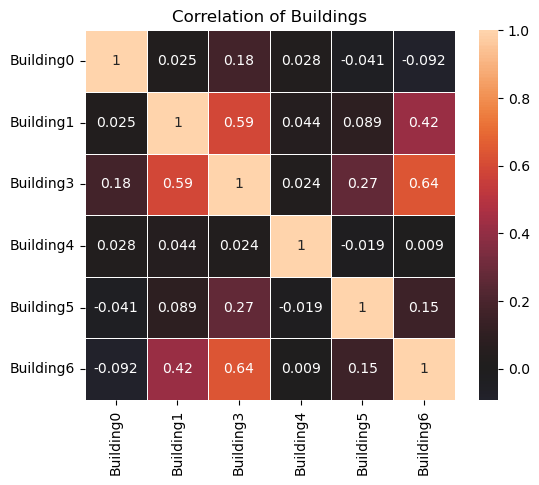

In [123]:
correlation = series_testing_dataset.iloc[:, :6].corr()
sns.heatmap(correlation, annot = True, center = 0, square = True, linewidth = .5);
plt.title("Correlation of Buildings")

Text(0.5, 1.0, 'Building0 Power Usage Series')

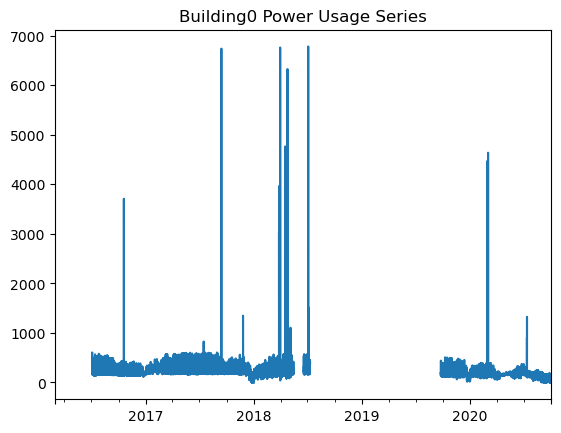

In [24]:
series_testing_dataset["Building0"].plot();
plt.title("Building0 Power Usage Series")

In [32]:
not_nan = True

for idx, item in series_testing_dataset["Building0"].items():
    if not_nan:
        if pd.isna(item):
            print("First NaN at:", idx)
            not_nan = False
    else:
        if not pd.isna(item):
            print("First non-NaN at:", idx)
            not_nan = True

First NaN at: 2016-03-01 04:15:00
First non-NaN at: 2016-07-03 21:30:00
First NaN at: 2016-10-18 15:15:00
First non-NaN at: 2016-10-18 21:30:00
First NaN at: 2017-09-12 16:15:00
First non-NaN at: 2017-09-13 03:45:00
First NaN at: 2017-11-14 15:15:00
First non-NaN at: 2017-11-14 20:00:00
First NaN at: 2017-11-14 20:15:00
First non-NaN at: 2017-11-14 22:15:00
First NaN at: 2017-11-25 02:30:00
First non-NaN at: 2017-11-25 06:15:00
First NaN at: 2017-12-26 01:15:00
First non-NaN at: 2017-12-26 02:15:00
First NaN at: 2017-12-31 01:15:00
First non-NaN at: 2017-12-31 06:15:00
First NaN at: 2018-01-01 02:15:00
First non-NaN at: 2018-01-01 06:15:00
First NaN at: 2018-03-21 04:30:00
First non-NaN at: 2018-03-21 04:45:00
First NaN at: 2018-03-26 05:30:00
First non-NaN at: 2018-03-26 16:15:00
First NaN at: 2018-03-27 16:15:00
First non-NaN at: 2018-03-28 08:30:00
First NaN at: 2018-03-29 06:30:00
First non-NaN at: 2018-03-30 16:45:00
First NaN at: 2018-04-04 06:15:00
First non-NaN at: 2018-04-06 0

Text(0.5, 1.0, 'Building1 Power Usage Series')

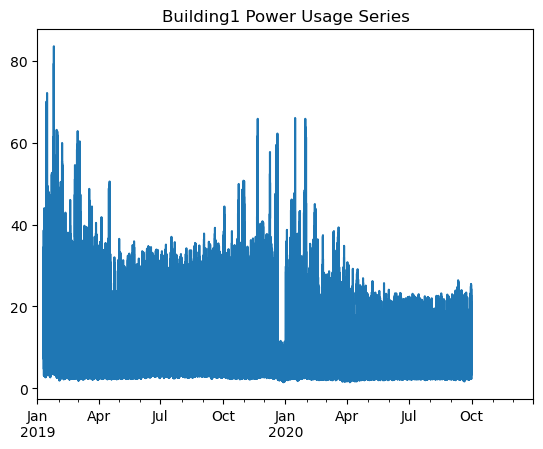

In [44]:
series_testing_dataset["Building1"].plot().set_xlim(pd.Timestamp("2019-01-01"),pd.Timestamp("2020-12-31"));
plt.title("Building1 Power Usage Series")

Text(0.5, 1.0, 'Building3 Power Usage Series')

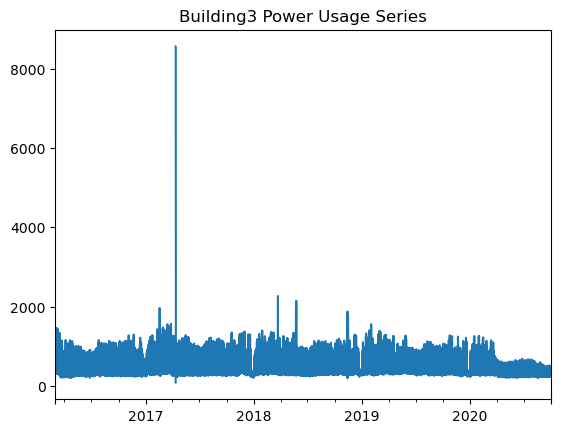

In [38]:
series_testing_dataset["Building3"].plot();
plt.title("Building3 Power Usage Series")

Text(0.5, 1.0, 'Building4 Power Usage Series')

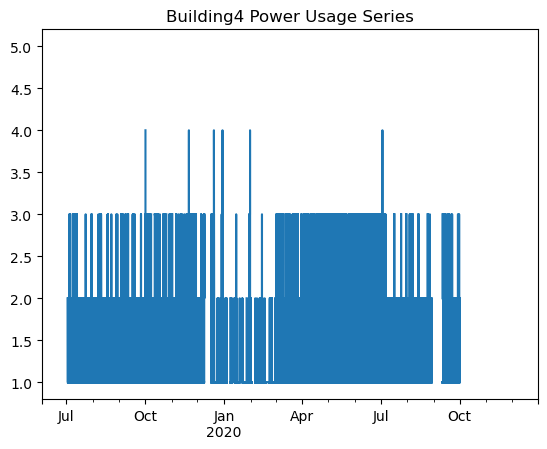

In [50]:
series_testing_dataset["Building4"].plot().set_xlim(pd.Timestamp("2019-06-03"),pd.Timestamp("2020-12-31"));
plt.title("Building4 Power Usage Series")

In [13]:
not_nan = True
first_nan = None

for idx, item in series_testing_dataset["Building4"].items():
    if not_nan:
        if pd.isna(item):
            first_nan = idx
            not_nan = False
    else:
        if not pd.isna(item):
            if idx - first_nan > pd.Timedelta("1 hour"):
                print('Start Nan at:', first_nan )
                print("Final non-NaN at:", idx)
                not_nan = True
                first_nan = None
            not_nan = True

Start Nan at: 2019-07-10 02:15:00
Final non-NaN at: 2019-07-10 03:45:00
Start Nan at: 2019-07-10 04:00:00
Final non-NaN at: 2019-07-10 05:15:00
Start Nan at: 2019-07-10 05:30:00
Final non-NaN at: 2019-07-10 07:15:00
Start Nan at: 2019-07-10 07:30:00
Final non-NaN at: 2019-07-10 09:15:00
Start Nan at: 2019-07-10 09:30:00
Final non-NaN at: 2019-07-10 11:15:00
Start Nan at: 2019-07-10 11:30:00
Final non-NaN at: 2019-07-10 13:00:00
Start Nan at: 2019-07-10 13:15:00
Final non-NaN at: 2019-07-10 14:45:00
Start Nan at: 2019-07-10 15:00:00
Final non-NaN at: 2019-07-10 16:30:00
Start Nan at: 2019-07-10 16:45:00
Final non-NaN at: 2019-07-10 18:00:00
Start Nan at: 2019-07-10 18:15:00
Final non-NaN at: 2019-07-10 19:45:00
Start Nan at: 2019-07-10 20:00:00
Final non-NaN at: 2019-07-10 21:45:00
Start Nan at: 2019-08-24 05:15:00
Final non-NaN at: 2019-08-24 06:30:00
Start Nan at: 2019-08-24 06:45:00
Final non-NaN at: 2019-08-24 08:00:00
Start Nan at: 2019-08-31 05:30:00
Final non-NaN at: 2019-08-31 0

Text(0.5, 1.0, 'Building5 Power Usage Series')

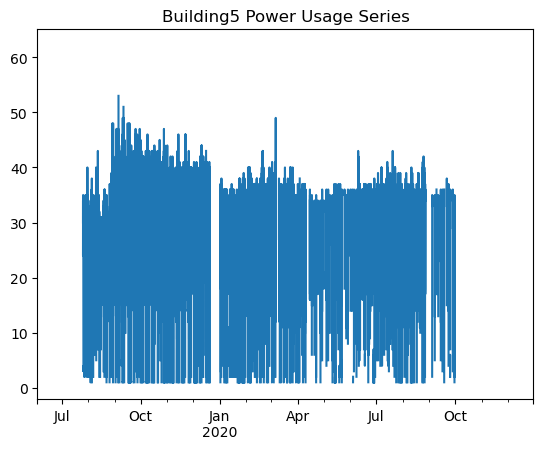

In [52]:
series_testing_dataset["Building5"].plot().set_xlim(pd.Timestamp("2019-06-03"),pd.Timestamp("2020-12-31"));
plt.title("Building5 Power Usage Series")

Text(0.5, 1.0, 'Building6 Power Usage Series')

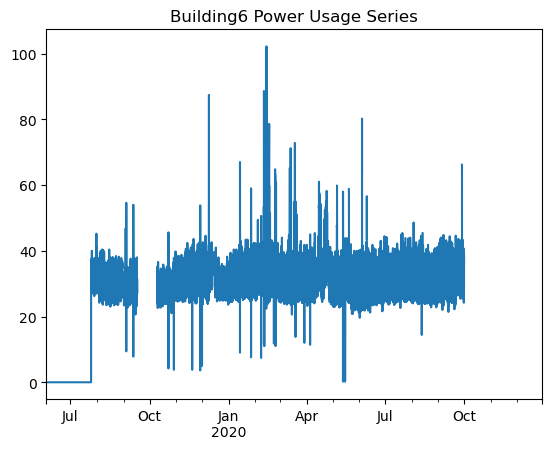

In [ ]:
series_testing_dataset["Building6"].plot().set_xlim(pd.Timestamp("2019-06-03"),pd.Timestamp("2020-12-31"));
plt.title("Building6 Power Usage Series") 	

In [16]:
not_nan = True
first_nan = None

for idx, item in series_testing_dataset["Building6"].items():
    if not_nan:
        if pd.isna(item):
            first_nan = idx
            not_nan = False
    else:
        if not pd.isna(item):
            if idx - first_nan > pd.Timedelta("1 hour"):
                print('Start Nan at:', first_nan )
                print("Final non-NaN at:", idx)
                not_nan = True
                first_nan = None
            not_nan = True

Start Nan at: 2019-09-16 16:00:00
Final non-NaN at: 2019-10-09 19:45:00


# Weather Data Analysis and Outliers

Text(0.5, 1.0, 'Correlation of Weather Features')

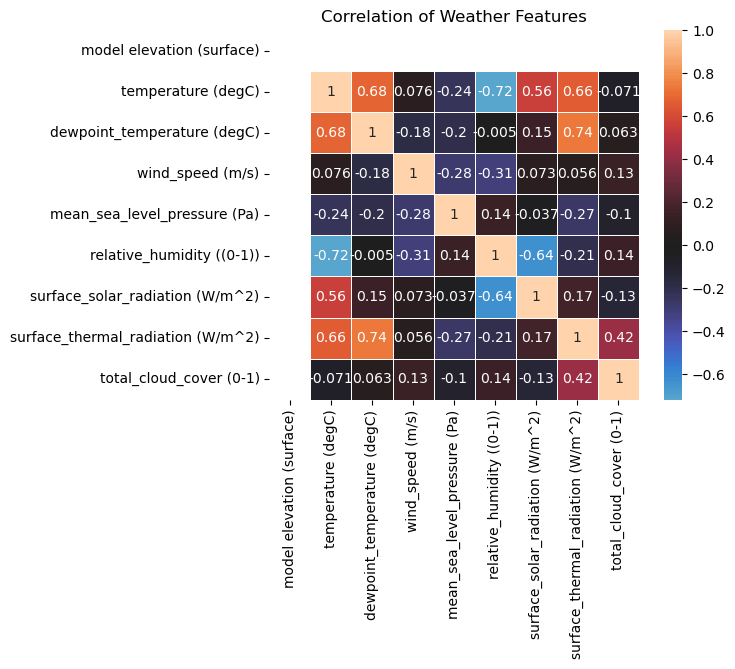

In [222]:
correlation = New_Weatherset.corr()
sns.heatmap(correlation, annot = True, center = 0, square = True, linewidth = .5);
plt.title("Correlation of Weather Features")

# DataFrames for Building Training Sets

### Building0 Dataset

In [22]:
Building0_Dataset = pd.concat([series_testing_dataset.loc["2016-07-03 21:30:00" : "2018-05-14 18:30:00", "Building0"],
                               series_testing_dataset.loc["2019-09-24 00:15:00": "2020-09-30 23:45:00", "Building0"]])
Building0_Dataset

2016-07-03 21:30:00    283.8
2016-07-03 21:45:00    283.8
2016-07-03 22:00:00    283.8
2016-07-03 22:15:00    606.0
2016-07-03 22:30:00    606.0
                       ...  
2020-09-30 22:45:00     96.9
2020-09-30 23:00:00     96.9
2020-09-30 23:15:00     37.4
2020-09-30 23:30:00     37.4
2020-09-30 23:45:00     37.4
Name: Building0, Length: 101076, dtype: float64

### Building1 Dataset

In [23]:
Building1_Dataset = series_testing_dataset.loc["2019-01-09 23:15:00" :"2020-09-30 23:45:00", "Building1"]

Building1_Dataset

2019-01-09 23:15:00     8.1
2019-01-09 23:30:00    15.7
2019-01-09 23:45:00    22.8
2019-01-10 00:00:00    32.7
2019-01-10 00:15:00     8.1
                       ... 
2020-09-30 22:45:00    14.4
2020-09-30 23:00:00    18.8
2020-09-30 23:15:00     4.5
2020-09-30 23:30:00     9.6
2020-09-30 23:45:00    14.0
Freq: 15min, Name: Building1, Length: 60483, dtype: float64

### Building3 Dataset

In [24]:
Building3_Dataset = series_testing_dataset.loc["2017-01-01 00:00:00" : "2020-09-30 23:45:00", "Building3"]

Building3_Dataset

2017-01-01 00:00:00    310.0
2017-01-01 00:15:00    331.0
2017-01-01 00:30:00    331.0
2017-01-01 00:45:00    331.0
2017-01-01 01:00:00    331.0
                       ...  
2020-09-30 22:45:00    389.0
2020-09-30 23:00:00    389.0
2020-09-30 23:15:00    415.0
2020-09-30 23:30:00    415.0
2020-09-30 23:45:00    415.0
Freq: 15min, Name: Building3, Length: 131424, dtype: float64

### Building4 Dataset

In [25]:
Building4_Dataset = series_testing_dataset.loc["2019-07-03 04:45:00" : "2020-09-30 23:45:00", "Building4"]

Building4_Dataset

2019-07-03 04:45:00    2.0
2019-07-03 05:00:00    NaN
2019-07-03 05:15:00    1.0
2019-07-03 05:30:00    2.0
2019-07-03 05:45:00    NaN
                      ... 
2020-09-30 22:45:00    NaN
2020-09-30 23:00:00    1.0
2020-09-30 23:15:00    NaN
2020-09-30 23:30:00    NaN
2020-09-30 23:45:00    NaN
Freq: 15min, Name: Building4, Length: 43757, dtype: float64

### Building6 Dataset

In [26]:
Building6_Dataset = pd.concat([series_testing_dataset.loc["2019-07-25 01:45:00":"2019-09-16 16:00:00", "Building6"],
                               series_testing_dataset.loc["2019-10-09 19:45:00": "2020-09-30 23:45:00", "Building6"]])
Building6_Dataset

2019-07-25 01:45:00    36.8
2019-07-25 02:00:00    34.6
2019-07-25 02:15:00    34.6
2019-07-25 02:30:00    36.2
2019-07-25 02:45:00    36.2
                       ... 
2020-09-30 22:45:00    35.6
2020-09-30 23:00:00    38.6
2020-09-30 23:15:00    38.6
2020-09-30 23:30:00    38.6
2020-09-30 23:45:00    38.6
Name: Building6, Length: 39435, dtype: float64

# Normalisation

# Resampling Data (Comparing Distribution)

In [102]:
Daily_testing_dataset = series_testing_dataset.resample("1D").mean()
Daily_testing_dataset.describe()

,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
count,1074.000000,631.000000,1671.000000,456.000000,328.000000,412.000000,159.000000,640.000000,484.000000,484.000000,484.000000,625.000000
mean,233.114583,11.377331,518.014621,1.292274,24.300126,30.708883,4.370343,1.937788,1.875435,1.356527,1.115974,3.887618
std,76.781811,3.473501,138.076034,0.198132,4.728872,2.918300,3.442808,2.120086,1.480630,1.152302,0.815465,4.330448
min,104.287500,5.463542,235.093750,1.000000,1.571429,24.579167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,186.319010,9.118750,387.390625,1.144148,23.919172,28.330208,1.790677,0.000000,0.592396,0.581094,0.442318,0.000000
50%,233.868229,10.996875,545.510417,1.287775,25.500000,31.092708,3.719896,1.532188,1.680677,1.327708,1.073438,2.442917
75%,271.279948,13.436979,629.625000,1.421768,26.877081,32.451562,7.050000,3.214974,3.106458,1.962005,1.750469,7.335521
max,1361.860000,27.884375,961.037975,1.916667,29.750000,45.416667,12.945104,9.485000,4.708958,7.946979,2.782187,13.561979


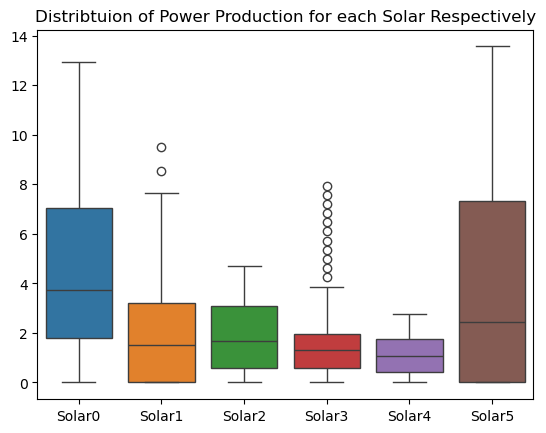

In [104]:
sns.boxplot(data = Daily_testing_dataset.iloc[:, 6:])
plt.title("Distribtuion of Power Production for each Solar Respectively");

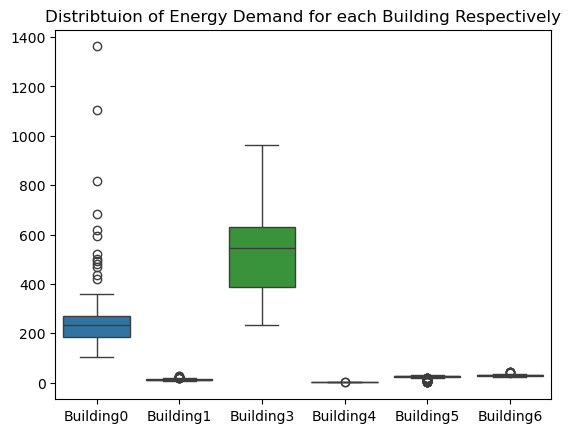

In [106]:
sns.boxplot(data = Daily_testing_dataset.iloc[:, :6])
plt.title("Distribtuion of Energy Demand for each Building Respectively");

<Axes: >

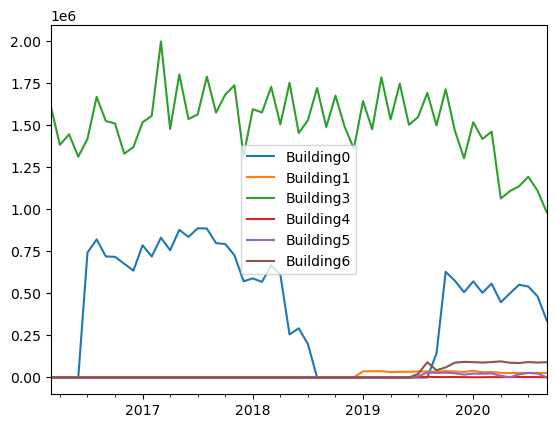

In [73]:
Daily_testing_dataset.iloc[:,:6].plot()

# Imputation

In [52]:
series_testing_dataset.fillna(0,inplace = True)
print("New size of data set after dropping NA Values",series_testing_dataset.shape)
series_testing_dataset.describe()

New size of data set after dropping NA Values (160783, 12)


,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
count,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000,160783.000000
mean,145.129691,4.272705,516.128533,0.215520,1.776512,7.524868,0.414900,0.739693,0.541974,0.392017,0.322501,1.450757
std,153.556455,7.338358,275.028970,0.534302,7.038648,13.494554,3.011701,2.321565,1.881633,1.338929,1.136258,5.661619
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,307.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,163.300000,0.000000,391.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,245.000000,7.100000,721.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6781.500000,83.500000,8556.000000,5.000000,62.000000,102.200000,50.410000,13.040000,13.960000,11.040000,8.100000,40.430000


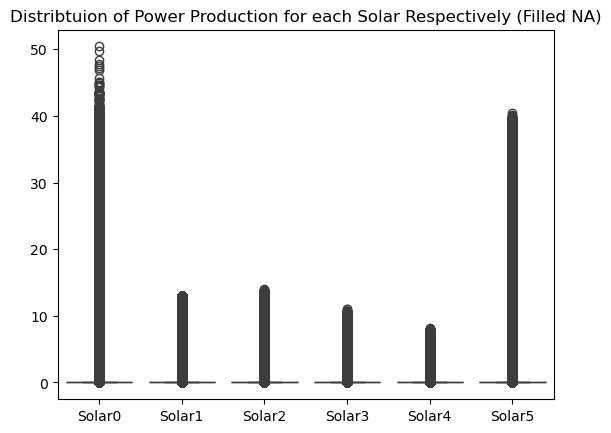

In [44]:
sns.boxplot(data = series_testing_dataset.iloc[:, 6:])
plt.title("Distribtuion of Power Production for each Solar Respectively (Filled NA)");

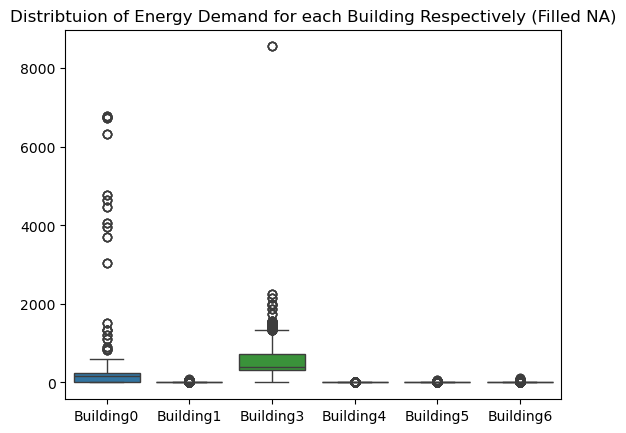

In [46]:
sns.boxplot(data = series_testing_dataset.iloc[:, :6])
plt.title("Distribtuion of Energy Demand for each Building Respectively (Filled NA)");